In [1]:
from QiskitTranspiler.transpiler.passes.layout.layout import Layout
from qiskit import QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_aer import AerSimulator
from QiskitTranspiler.transpiler.passes.translation.translator import translate_circuit
from qiskit.converters import circuit_to_dag, dag_to_circuit
from QiskitTranspiler.transpiler.transpile import transpile

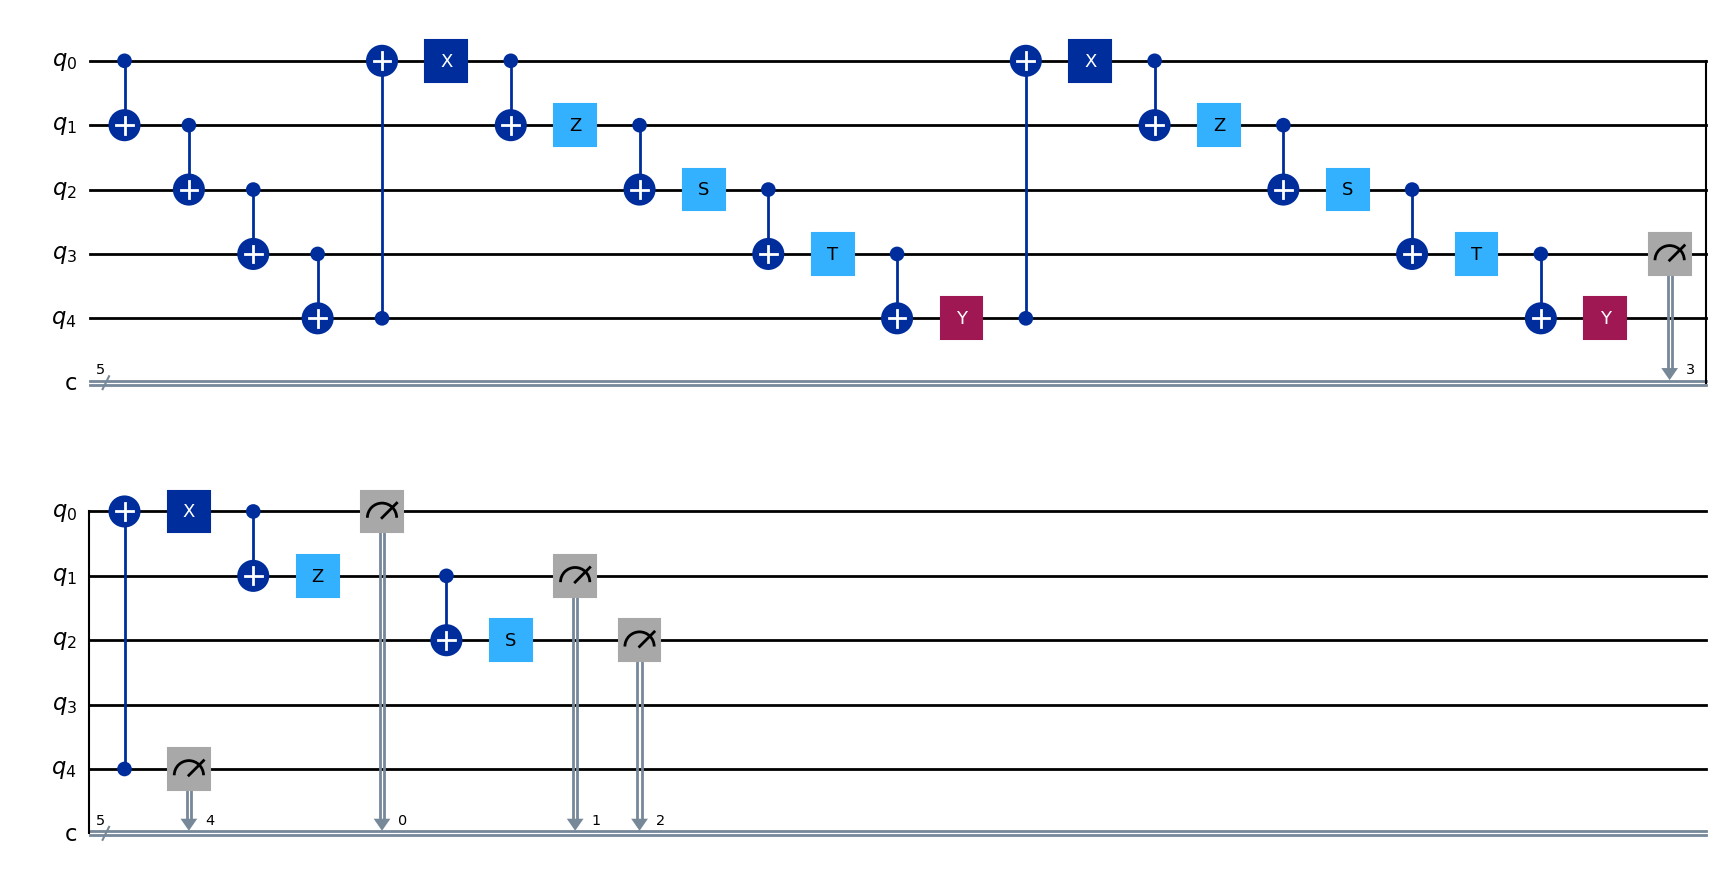

In [2]:
qc = QuantumCircuit(5, 5)
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)
qc.cx(3, 4)
qc.cx(4, 0)
qc.x(0)
qc.cx(0, 1)
qc.z(1)
qc.cx(1, 2)
qc.s(2)
qc.cx(2, 3)
qc.t(3)
qc.cx(3, 4)
qc.y(4)
qc.cx(4, 0)
qc.x(0)
qc.cx(0, 1)
qc.z(1)
qc.cx(1, 2)
qc.s(2)
qc.cx(2, 3)
qc.t(3)
qc.cx(3, 4)
qc.y(4)
qc.cx(4, 0)
qc.x(0)
qc.cx(0, 1)
qc.z(1)
qc.cx(1, 2)
qc.s(2)
qc.measure([0, 1, 2, 3, 4], [0, 1, 2, 3, 4])
qc.draw("mpl")

# Simulated Hardware
## Run the circuit 50 times with the custom transpiler and then with the Qiskit transpiler

In [3]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

#Testing first with a simulator, then with a real backend
backend = FakeFez()

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [5]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "01001":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.17537109375
Errors for each run: [0.1865234375, 0.1826171875, 0.1640625, 0.1669921875, 0.171875, 0.1513671875, 0.1669921875, 0.1982421875, 0.16796875, 0.1845703125, 0.17578125, 0.181640625, 0.185546875, 0.19140625, 0.169921875, 0.2060546875, 0.142578125, 0.1845703125, 0.1767578125, 0.1650390625, 0.1806640625, 0.17578125, 0.15625, 0.1591796875, 0.1796875, 0.1552734375, 0.171875, 0.1767578125, 0.154296875, 0.1826171875, 0.1640625, 0.205078125, 0.1923828125, 0.15625, 0.1796875, 0.1689453125, 0.1953125, 0.1796875, 0.171875, 0.1728515625, 0.1611328125, 0.1806640625, 0.171875, 0.1669921875, 0.171875, 0.1904296875, 0.173828125, 0.197265625, 0.171875, 0.18359375]


In [1]:
import numpy as np
errors = [0.1865234375, 0.1826171875, 0.1640625, 0.1669921875, 0.171875, 0.1513671875, 0.1669921875, 0.1982421875, 0.16796875, 0.1845703125, 0.17578125, 0.181640625, 0.185546875, 0.19140625, 0.169921875, 0.2060546875, 0.142578125, 0.1845703125, 0.1767578125, 0.1650390625, 0.1806640625, 0.17578125, 0.15625, 0.1591796875, 0.1796875, 0.1552734375, 0.171875, 0.1767578125, 0.154296875, 0.1826171875, 0.1640625, 0.205078125, 0.1923828125, 0.15625, 0.1796875, 0.1689453125, 0.1953125, 0.1796875, 0.171875, 0.1728515625, 0.1611328125, 0.1806640625, 0.171875, 0.1669921875, 0.171875, 0.1904296875, 0.173828125, 0.197265625, 0.171875, 0.18359375]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.17537109375
Standard deviation of errors over 50 runs: 0.013564154317488164
0.1754 ± 0.0038 (95% CI)


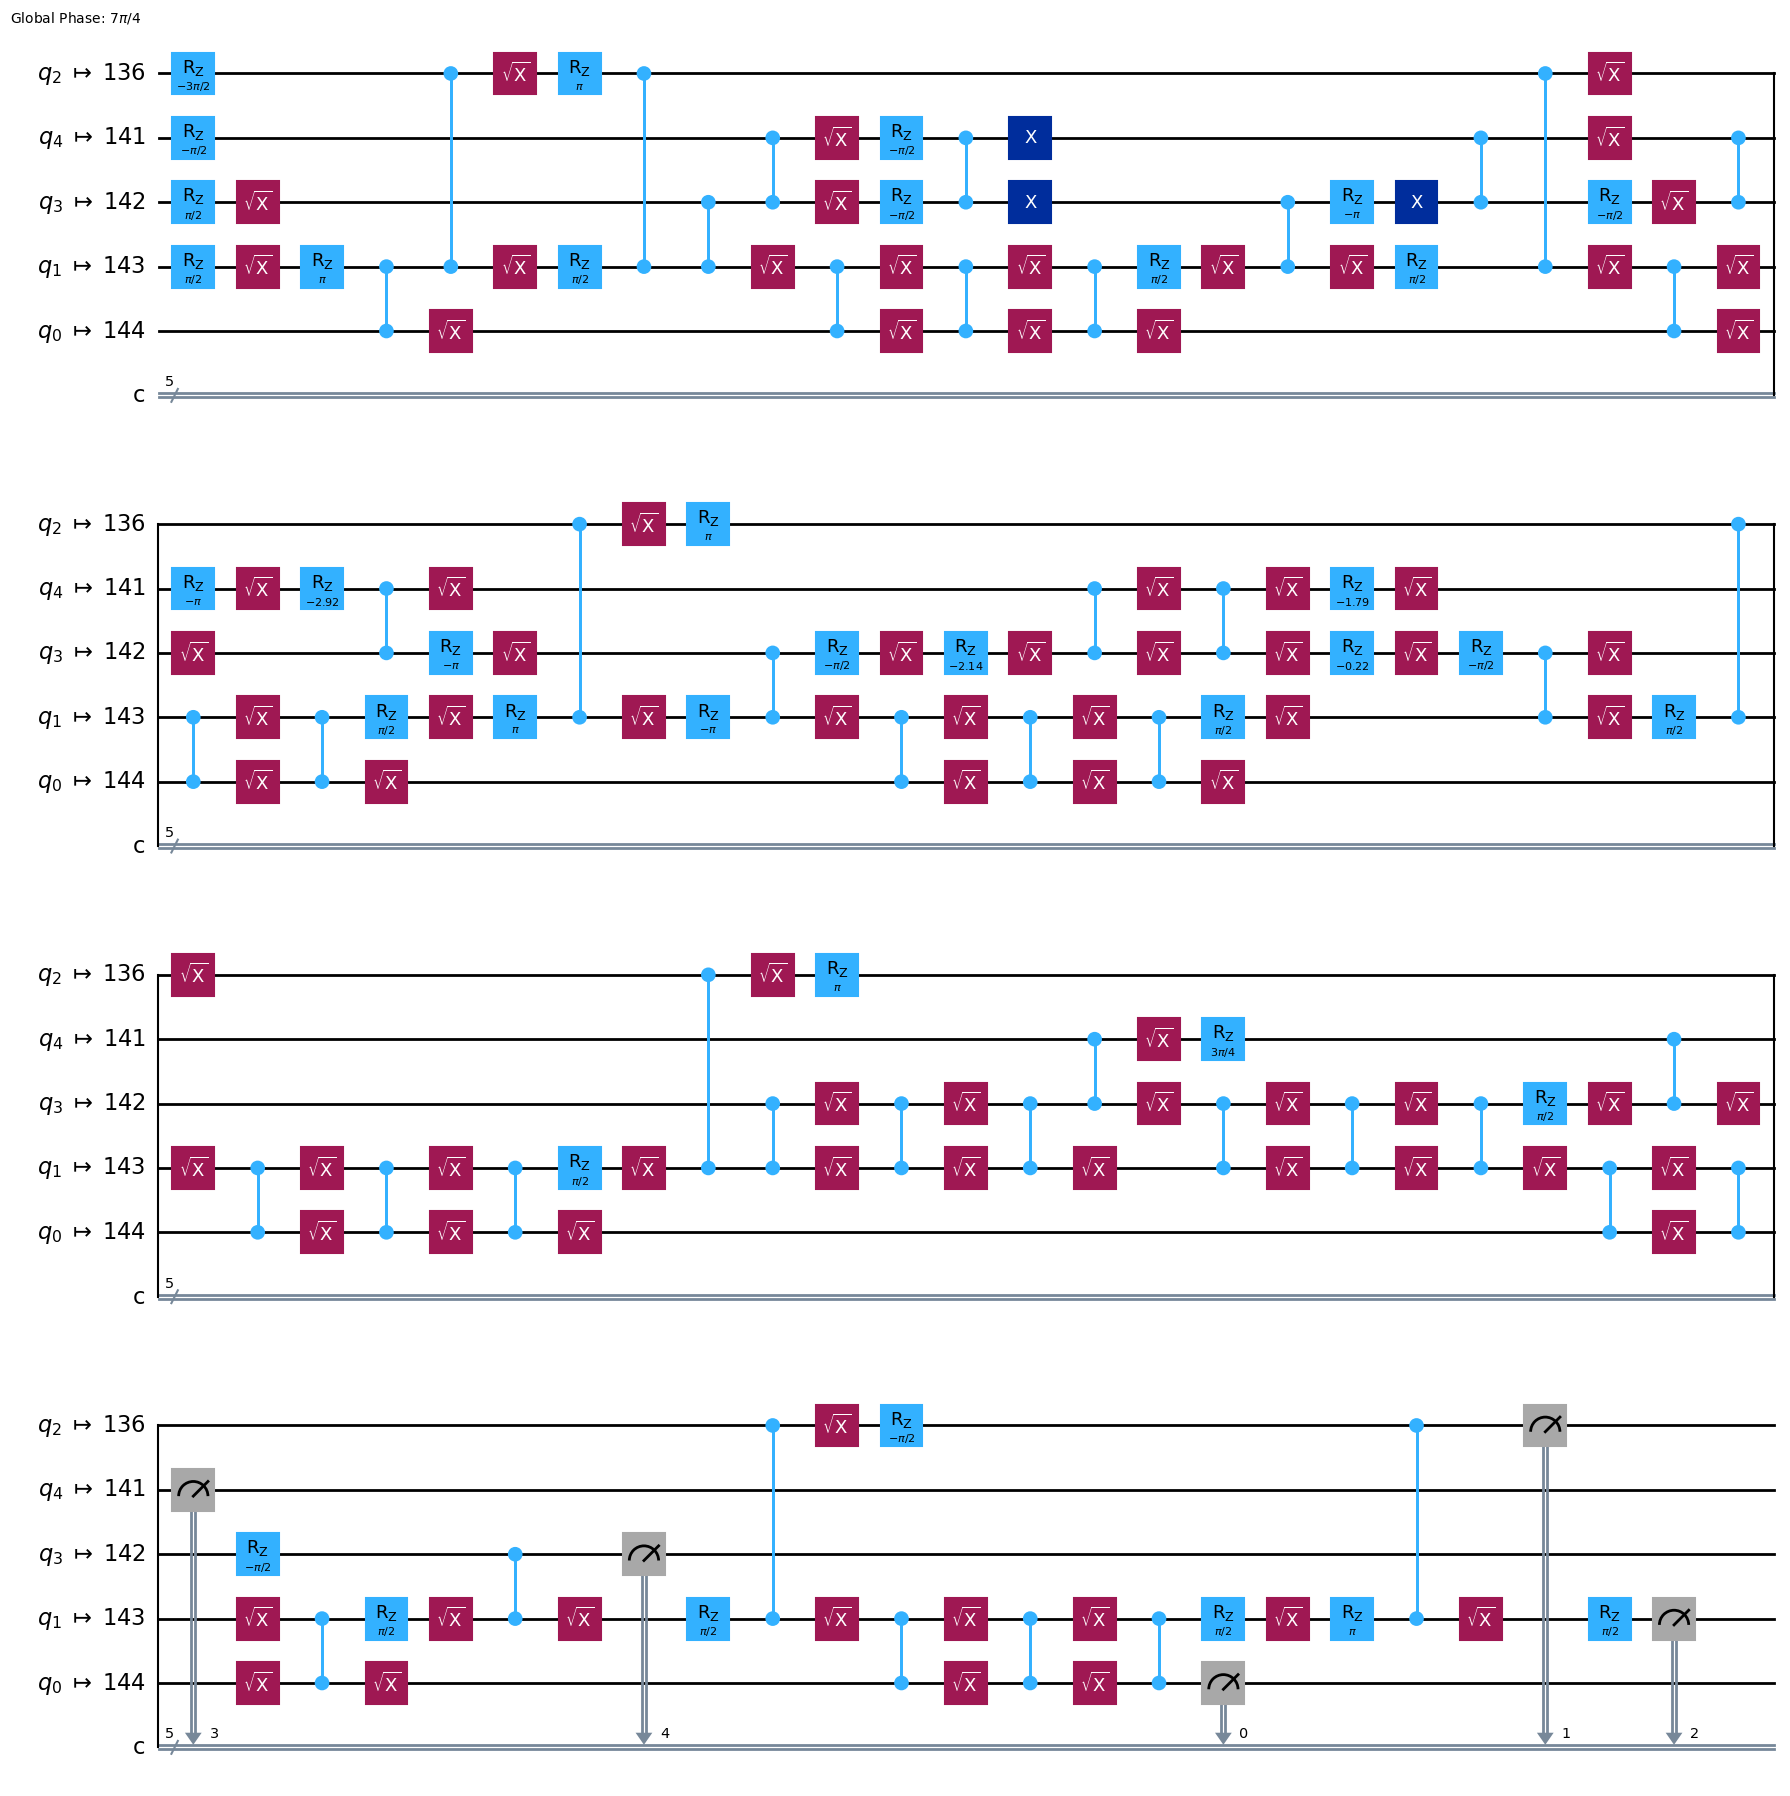

In [6]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit import transpile

#Testing first with a simulator, then with a real backend
backend = FakeFez()

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")

In [7]:
sampler = Sampler(mode=backend)

experiment_errors = []

for _ in range(50):
    job = sampler.run([transpiled_circuit], shots=1024)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "01001":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)

print("Average error over 50 runs (Qiskit transpiler):", sum(experiment_errors) / len(experiment_errors))
print("Errors for each run:", experiment_errors)

Average error over 50 runs (Qiskit transpiler): 0.1601953125
Errors for each run: [0.146484375, 0.1669921875, 0.1572265625, 0.1474609375, 0.162109375, 0.1767578125, 0.16015625, 0.16015625, 0.1630859375, 0.150390625, 0.1630859375, 0.1533203125, 0.15625, 0.1494140625, 0.1455078125, 0.158203125, 0.158203125, 0.185546875, 0.177734375, 0.146484375, 0.146484375, 0.16796875, 0.1630859375, 0.171875, 0.146484375, 0.140625, 0.15625, 0.16015625, 0.1552734375, 0.1748046875, 0.1474609375, 0.185546875, 0.1494140625, 0.1689453125, 0.1611328125, 0.16796875, 0.17578125, 0.18359375, 0.1552734375, 0.1689453125, 0.1591796875, 0.1591796875, 0.134765625, 0.14453125, 0.154296875, 0.15234375, 0.1708984375, 0.162109375, 0.1728515625, 0.16796875]


In [2]:
import numpy as np
errors = [0.146484375, 0.1669921875, 0.1572265625, 0.1474609375, 0.162109375, 0.1767578125, 0.16015625, 0.16015625, 0.1630859375, 0.150390625, 0.1630859375, 0.1533203125, 0.15625, 0.1494140625, 0.1455078125, 0.158203125, 0.158203125, 0.185546875, 0.177734375, 0.146484375, 0.146484375, 0.16796875, 0.1630859375, 0.171875, 0.146484375, 0.140625, 0.15625, 0.16015625, 0.1552734375, 0.1748046875, 0.1474609375, 0.185546875, 0.1494140625, 0.1689453125, 0.1611328125, 0.16796875, 0.17578125, 0.18359375, 0.1552734375, 0.1689453125, 0.1591796875, 0.1591796875, 0.134765625, 0.14453125, 0.154296875, 0.15234375, 0.1708984375, 0.162109375, 0.1728515625, 0.16796875]
mean_error = np.mean(errors)
print("Mean error over 50 runs:", mean_error)
std = np.std(errors)
print("Standard deviation of errors over 50 runs:", std)
ci95 = 1.96 * std / np.sqrt(len(errors))
print(f"{mean_error:.4f} ± {ci95:.4f} (95% CI)")

Mean error over 50 runs: 0.1601953125
Standard deviation of errors over 50 runs: 0.011690982728087383
0.1602 ± 0.0032 (95% CI)


# REAL QUANTUM HARDWARE
## We run each circuit 10 times with the custom transpiler and 10 times with the Qiskit transpiler

In [8]:
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeTorino, FakeMarrakesh, FakePerth
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()

# See all available backends
for b in service.backends():
    print(b.name, b.num_qubits, b.status().pending_jobs)

ibm_fez 156 0
ibm_marrakesh 156 0
ibm_kingston 156 0


In [9]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from QiskitTranspiler.transpiler.transpile import transpile

transpiled_circuit = transpile(qc, backend)
# transpiled_circuit.draw("mpl")

Running on: ibm_fez (156 qubits)
[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'


In [10]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7du0mb0g7hs73dsclvg
Job ID: d7du0mjklj2c73f24hig
Job ID: d7du0mu5nvhs73a64os0
Job ID: d7du0mr0g7hs73dscm0g
Job ID: d7du0nbklj2c73f24hk0
Job ID: d7du0nm5nvhs73a64ot0
Job ID: d7du0nj0g7hs73dscm20
Job ID: d7du0nrklj2c73f24hmg
Job ID: d7du0o15a5qc73dqac30
Job ID: d7du0obklj2c73f24hng


In [11]:
job_ids = [
    "d7du0mb0g7hs73dsclvg",
    "d7du0mjklj2c73f24hig",
    "d7du0mu5nvhs73a64os0",
    "d7du0mr0g7hs73dscm0g",
    "d7du0nbklj2c73f24hk0",
    "d7du0nm5nvhs73a64ot0",
    "d7du0nj0g7hs73dscm20",
    "d7du0nrklj2c73f24hmg",
    "d7du0o15a5qc73dqac30",
    "d7du0obklj2c73f24hng",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "01001":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7du0mb0g7hs73dsclvg: error = 0.2988
Job d7du0mjklj2c73f24hig: error = 0.3105
Job d7du0mu5nvhs73a64os0: error = 0.3486
Job d7du0mr0g7hs73dscm0g: error = 0.3281
Job d7du0nbklj2c73f24hk0: error = 0.3271
Job d7du0nm5nvhs73a64ot0: error = 0.3018
Job d7du0nj0g7hs73dscm20: error = 0.3525
Job d7du0nrklj2c73f24hmg: error = 0.3164
Job d7du0o15a5qc73dqac30: error = 0.3398
Job d7du0obklj2c73f24hng: error = 0.3115

Average error over runs: 0.32353515625


Running on: ibm_fez (156 qubits)


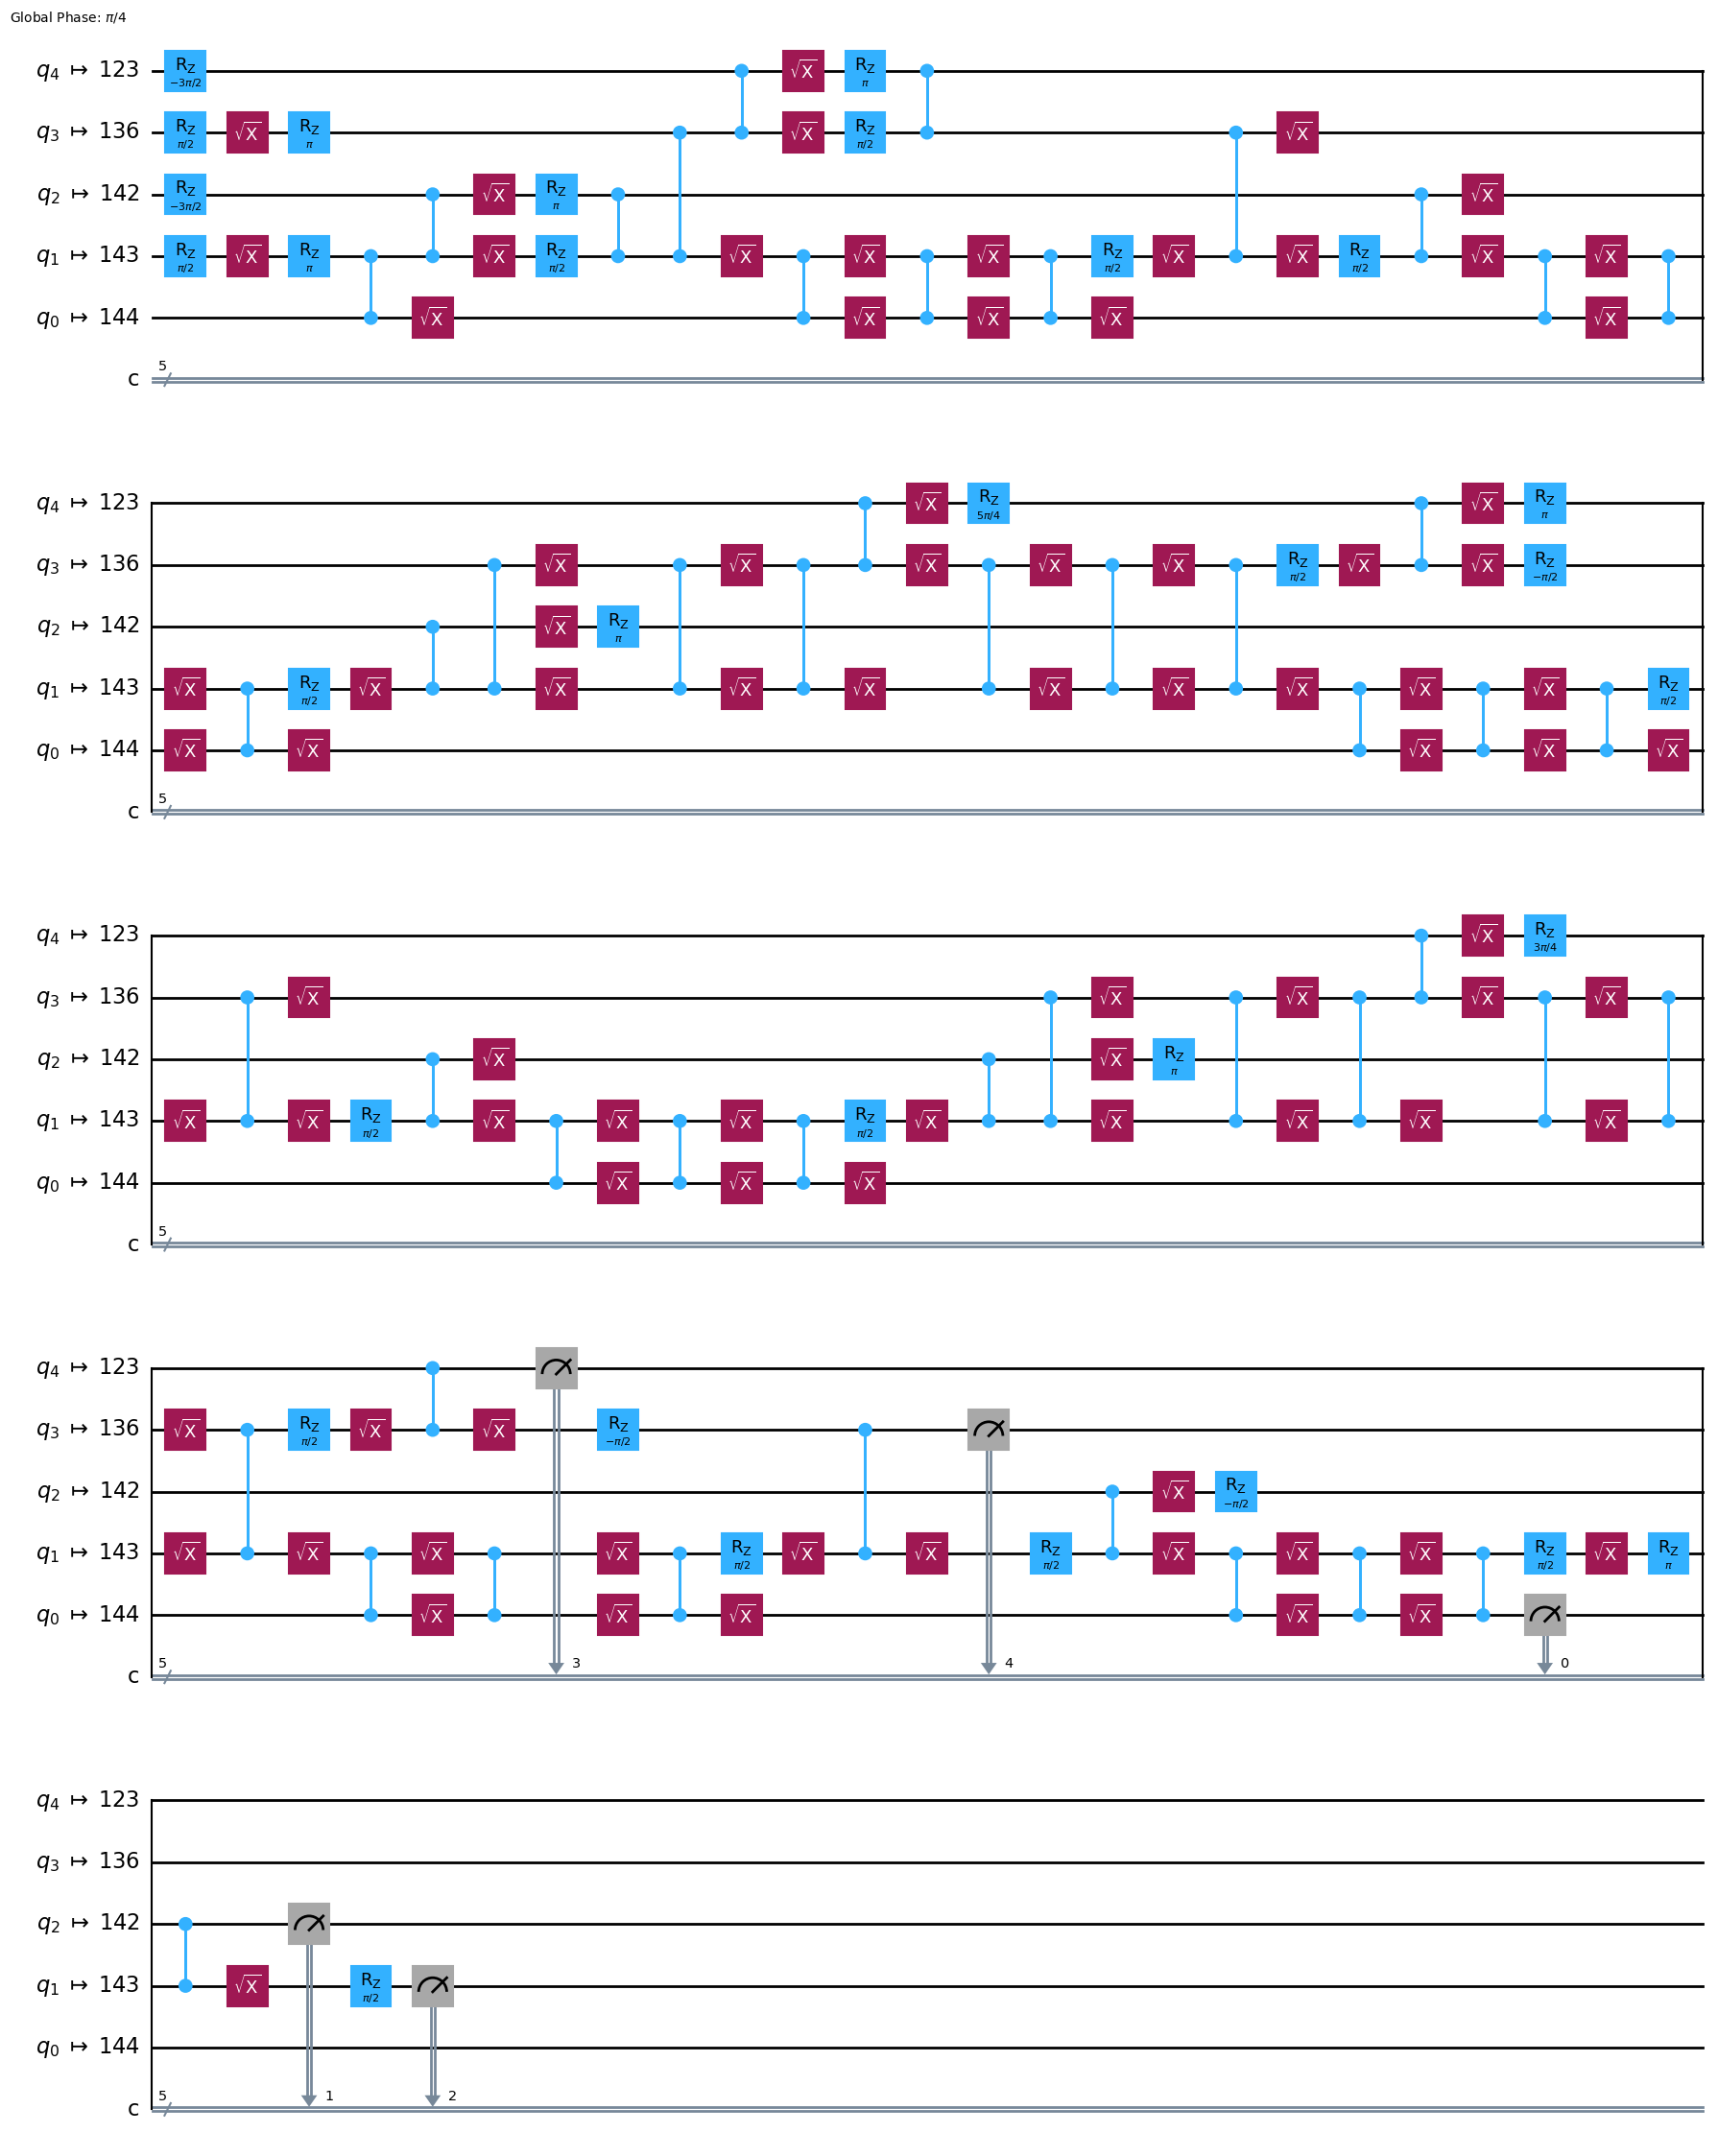

In [12]:
backend = service.backend("ibm_fez")
print(f"Running on: {backend.name} ({backend.num_qubits} qubits)")

from qiskit import transpile

transpiled_circuit = transpile(qc, backend)
transpiled_circuit.draw("mpl")
# qc.draw("mpl")

In [13]:
sampler = Sampler(mode=backend)
sampler.options.default_shots = 1024

for i in range(10):
    job = sampler.run([transpiled_circuit])
    print(f"Job ID: {job.job_id()}")

Job ID: d7du7mjklj2c73f24p40
Job ID: d7du7mrklj2c73f24p4g
Job ID: d7du7n15a5qc73dqajhg
Job ID: d7du7nb0g7hs73dsctag
Job ID: d7du7nj0g7hs73dsctbg
Job ID: d7du7np5a5qc73dqajj0
Job ID: d7du7nrklj2c73f24p70
Job ID: d7du7o30g7hs73dsctdg
Job ID: d7du7oe5nvhs73a65050
Job ID: d7du7oj0g7hs73dscte0


In [14]:
job_ids = [
    "d7du7mjklj2c73f24p40",
    "d7du7mrklj2c73f24p4g",
    "d7du7n15a5qc73dqajhg",
    "d7du7nb0g7hs73dsctag",
    "d7du7nj0g7hs73dsctbg",
    "d7du7np5a5qc73dqajj0",
    "d7du7nrklj2c73f24p70",
    "d7du7o30g7hs73dsctdg",
    "d7du7oe5nvhs73a65050",
    "d7du7oj0g7hs73dscte0",
]

experiment_errors = []

for job_id in job_ids:
    job = service.job(job_id)
    counts = job.result()[0].join_data().get_counts()

    acc_sum = 0
    for state, count in counts.items():
        if state != "01001":
            acc_sum += count
    error = acc_sum / 1024
    experiment_errors.append(error)
    print(f"Job {job_id}: error = {error:.4f}")

print("\nAverage error over runs:", sum(experiment_errors) / len(experiment_errors))
# print("Errors for each run:", experiment_errors)

Job d7du7mjklj2c73f24p40: error = 0.2246
Job d7du7mrklj2c73f24p4g: error = 0.2656
Job d7du7n15a5qc73dqajhg: error = 0.2559
Job d7du7nb0g7hs73dsctag: error = 0.2324
Job d7du7nj0g7hs73dsctbg: error = 0.2344
Job d7du7np5a5qc73dqajj0: error = 0.2490
Job d7du7nrklj2c73f24p70: error = 0.2334
Job d7du7o30g7hs73dsctdg: error = 0.2539
Job d7du7oe5nvhs73a65050: error = 0.2793
Job d7du7oj0g7hs73dscte0: error = 0.2471

Average error over runs: 0.24755859375


In [3]:
import time
from QiskitTranspiler.transpiler.transpile import transpile
from qiskit_ibm_runtime.fake_provider import FakeFez

backend = FakeFez()

start = time.perf_counter()
transpiled_circuit = transpile(qc, backend)
elapsed = time.perf_counter() - start

print("Original circuit:")
print(f"No. of Gates: {qc.size()}")
print(f"Depth: {qc.depth()}\n")

print("My transpiler:")
print(f"No. of Gates: {transpiled_circuit.size()}")
print(f"Depth: {transpiled_circuit.depth()}")
print(f"Transpilation time: {elapsed:.4f} seconds")

from qiskit import transpile

start = time.perf_counter()
transpiled_circuit = transpile(qc, backend)
elapsed = time.perf_counter() - start

print("\nQiskit transpiler:")
print(f"No. of Gates: {transpiled_circuit.size()}")
print(f"Depth: {transpiled_circuit.depth()}")
print(f"Transpilation time: {elapsed:.4f} seconds")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
Original circuit:
No. of Gates: 35
Depth: 31

My transpiler:
No. of Gates: 446
Depth: 260
Transpilation time: 2.0177 seconds

Qiskit transpiler:
No. of Gates: 180
Depth: 97
Transpilation time: 0.0460 seconds


In [17]:
from QiskitTranspiler.transpiler.transpile import transpile
from qiskit_ibm_runtime.fake_provider import FakeFez

backend = FakeFez()

transpiled_circuit = transpile(qc, backend)

print("Original circuit:")

twoq = sum(1 for inst in qc.data if len(inst.qubits) == 2)
oneq = sum(1 for inst in qc.data if len(inst.qubits) == 1)

print(f"\nOriginal circuit: {twoq} two-qubit gates, {oneq} single-qubit gates")

print("\nMy transpiler:")
twoq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 2)
oneq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 1)

print(f"\n {twoq} two-qubit gates, {oneq} single-qubit gates")

from qiskit import transpile

transpiled_circuit = transpile(qc, backend)


print("\nQiskit transpiler:")

twoq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 2)
oneq = sum(1 for inst in transpiled_circuit.data if len(inst.qubits) == 1)

print(f"\n {twoq} two-qubit gates, {oneq} single-qubit gates")

[BasisTranslator] Warning: Found a built-in equivalence table that covers the provided custom_basis. Using 'heron'
Original circuit:

Original circuit: 17 two-qubit gates, 18 single-qubit gates

My transpiler:

 62 two-qubit gates, 384 single-qubit gates

Qiskit transpiler:

 47 two-qubit gates, 133 single-qubit gates
